### Opis danych w tabelach (Kolumny 0-6)

Dane pochodzą z bazy nagrań Holtera i mają postać szeregów czasowych RR (czasów pomiędzy kolejnymi skurczami serca). Są to dane nierównomiernie próbkowane, odzwierciedlające regulację układu autonomicznego.

**Struktura kolumn w tablicach `chf_array` oraz `nsr_array`:**

* **Kolumna 0 (`n_intervals`):** Liczba interwałów RR w całym nagraniu.
* **Kolumna 1 (`mean_RR`):** Średni RR – średnia długość odstępu między skurczami.
* **Kolumna 2 (`std_RR`):** Odchylenie standardowe RR – podstawowa miara zmienności rytmu serca (HRV).
* **Kolumna 3 (`n_windows`):** Liczba okien (fragmentów), na które podzielono nagranie do analizy.
* **Kolumna 4 (`ApEn`):** Approximate Entropy (Entropia przybliżona) – miara nieliniowa określająca złożoność i przewidywalność sygnału.
* **Kolumna 5 (`SampEn`):** Sample Entropy (Entropia próbkowania) – udoskonalona miara nieliniowa, mniej zależna od długości szeregu czasowego.
* **Kolumna 6 (`Shannon`):** Entropia Shannona – miara stopnia nieuporządkowania danych.

In [11]:
import pandas as pd
import numpy as np

#Wczytanie jako tabele
chf_df = pd.read_csv('chf.csv')
nsr_df = pd.read_csv('nsr.csv')

#Konwersja na tablice numpy
# Usunięcie kolumny z file_name
chf_array = chf_df.drop(columns=['file_name']).to_numpy()
nsr_array = nsr_df.drop(columns=['file_name']).to_numpy()

# Sprawdzenie wymiarów
print(f"Tablica CHF ma rozmiar: {chf_array.shape}") # (wiersze, kolumny)
print(f"Tablica NSR ma rozmiar: {nsr_array.shape}")

Tablica CHF ma rozmiar: (29, 7)
Tablica NSR ma rozmiar: (54, 7)


**Poniższy kod przygotowuje zmienne (np. chf_mean, nsr_std), które są gotowymi wektorami statystyk.**

In [12]:
# 2. Obliczenia dla grupy CHF
chf_mean   = np.mean(chf_array, axis=0)   # Średnia
chf_median = np.median(chf_array, axis=0) # Mediana
chf_std    = np.std(chf_array, axis=0, ddof=1) # Odchylenie standardowe (ddof=1 daje wynik jak w Excelu/Pandas)

# 3. Obliczenia dla grupy NSR
nsr_mean   = np.mean(nsr_array, axis=0)
nsr_median = np.median(nsr_array, axis=0)
nsr_std    = np.std(nsr_array, axis=0, ddof=1)

# 4. Wyświetlenie wyników (przykład dla pierwszej cechy, czyli n_intervals)
print(f"Statystyki dla pierwszej kolumny (n_intervals) w grupie CHF:")
print(f"Średnia: {chf_mean[0]:.2f}, Mediana: {chf_median[0]:.2f}, Odchylenie: {chf_std[0]:.2f}")

Statystyki dla pierwszej kolumny (n_intervals) w grupie CHF:
Średnia: 107155.07, Mediana: 102645.00, Odchylenie: 19899.65


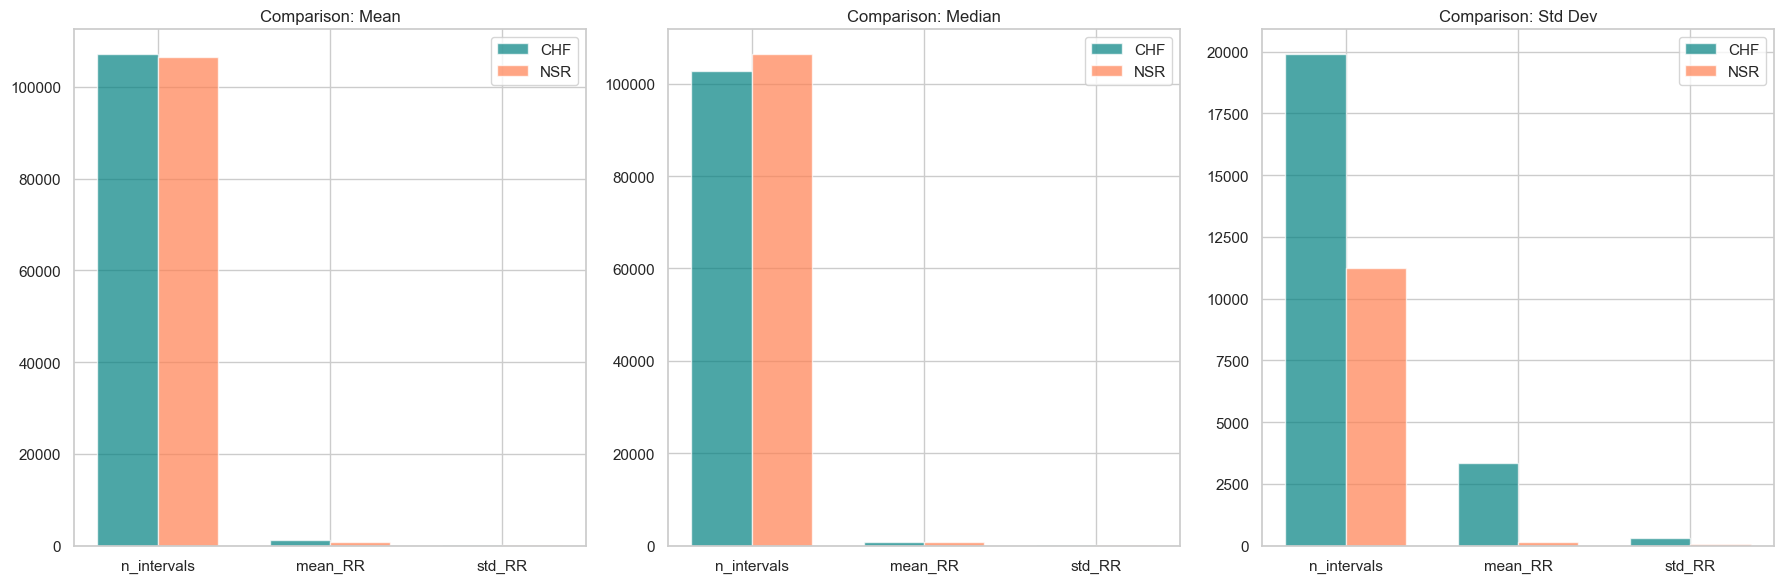

In [35]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Mean', 'Median', 'Std Dev']
chf_stats = [chf_mean, chf_median, chf_std]
nsr_stats = [nsr_mean, nsr_median, nsr_std]
column_names = ['n_intervals', 'mean_RR', 'std_RR']
x = np.arange(len(column_names))
width = 0.35

for i, ax in enumerate(axes):
    ax.bar(x - width/2, chf_stats[i][:3], width, label='CHF', color='teal', alpha=0.7)
    ax.bar(x + width/2, nsr_stats[i][:3], width, label='NSR', color='coral', alpha=0.7)
    ax.set_title(f'Comparison: {metrics[i]}')
    ax.set_xticks(x)
    ax.set_xticklabels(column_names)
    ax.legend()

plt.tight_layout()
plt.show()


ValueError: Could not interpret value `Grupa` for `x`. An entry with this name does not appear in `data`.

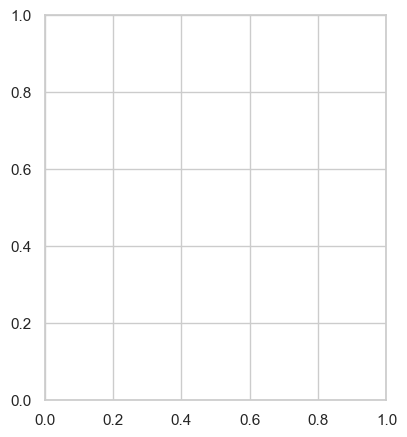

In [ ]:
import seaborn as sns
combined_df = pd.concat([chf_df, nsr_df], ignore_index=True)
plt.figure(figsize=(15, 5))
for i, feature in enumerate(['n_intervals', 'mean_RR', 'std_RR'], 1):
    plt.subplot(1, 3, i)
    combined_df = pd.concat([df_chf, df_nsr], ignore_index=True)

    plt.figure(figsize=(15, 5))
    for i, feature in enumerate(['n_intervals', 'mean_RR', 'std_RR'], 1):
        plt.subplot(1, 3, i)
        sns.boxplot(x='Grupa', y=feature, data=combined_df, palette='Set2')
        plt.title(f'Boxplot (Mediana): {feature}')

    plt.tight_layout()
    plt.show()
    plt.title(f'Boxplot (Mediana): {feature}')

plt.tight_layout()
plt.show()